Market Research: Social Influence on Consumer Behavior

1. Preprocessing - Cleaning and transforming data

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('Social Influencer Dataset.csv',header=1)
df.head()

,RQ1,RQ2,RQ3,RQ4,RQ5,RQ6,RQ7,RQ8,RQ9,RQ10,...,RQ52,RQ53,RQ54,RQ55,RQ56,RQ57,RQ58,RQ59,RQ60,RQ61
0,5.0,"Yes, I follow a lot (more than 25)",2,5,1,2,1,5.0,2,1.0,...,18-24,Male,High school graduate,Yes,Unemployed looking for work,"Less than $10,000",4.6,2.50,3.50,4.00
1,2.0,"Yes, I follow a few (less than 5)",4,4,4,4,3,4.0,4,5.0,...,18-24,Male,Bachelor's degree,Yes,Other,"Less than $10,000",4.6,4.25,3.75,4.00
2,4.0,"Yes, I follow a lot (more than 25)",3,3,3,3,3,3.0,4,1.0,...,24-34,Male,Bachelor's degree,Yes,Employed full time,"$10,000 - $29,999",3.6,3.50,3.25,3.75
3,4.0,"Yes, I follow a lot (more than 25)",3,2,2,4,2,2.0,3,3.0,...,18-24,Male,Bachelor's degree,Yes,Other,"Less than $10,000",4.2,3.50,4.00,3.50
4,4.0,"Yes, I follow a lot (more than 25)",3,4,2,3,2,4.0,3,1.0,...,18-24,Female,Associate's degree or Diploma,Yes,Employed part time,"Less than $10,000",2.4,2.75,3.00,1.00


In [24]:
df.isnull().sum()

RQ1     1
RQ2     0
RQ3     0
RQ4     0
RQ5     0
       ..
RQ57    3
RQ58    0
RQ59    0
RQ60    0
RQ61    0
Length: 61, dtype: int64

In [29]:
df_regression = df.loc[:,'RQ1':'RQ32']
df_regression.head()

,RQ1,RQ2,RQ3,RQ4,RQ5,RQ6,RQ7,RQ8,RQ9,RQ10,...,RQ23,RQ24,RQ25,RQ26,RQ27,RQ28,RQ29,RQ30,RQ31,RQ32
0,5.0,"Yes, I follow a lot (more than 25)",2,5,1,2,1,5.0,2,1.0,...,1,2,4,5,3,2,4,1,5,5
1,2.0,"Yes, I follow a few (less than 5)",4,4,4,4,3,4.0,4,5.0,...,5,2,4,4,4,3,5,4,4,3
2,4.0,"Yes, I follow a lot (more than 25)",3,3,3,3,3,3.0,4,1.0,...,2,4,3,3,4,3,2,3,3,3
3,4.0,"Yes, I follow a lot (more than 25)",3,2,2,4,2,2.0,3,3.0,...,3,3,4,4,4,4,4,4,5,4
4,4.0,"Yes, I follow a lot (more than 25)",3,4,2,3,2,4.0,3,1.0,...,3,3,3,3,3,3,3,3,3,3


In [36]:
df_regression['RQ2'].unique()

array([5, 'Yes, I follow a few (less than 5)',
       'Yes, I follow a many (between 5-24)', 'No'], dtype=object)

In [37]:
df_regression['RQ2']=df_regression['RQ2'].replace('Yes, I follow a lot (more than 25)',5)
df_regression['RQ2']=df_regression['RQ2'].replace('Yes, I follow a many (between 5-24)',4)
df_regression['RQ2']=df_regression['RQ2'].replace('Yes, I follow a few (less than 5)',3)
df_regression['RQ2']=df_regression['RQ2'].replace('Yes, but only 1 or 2',2)
df_regression['RQ2']=df_regression['RQ2'].replace('No',1)

C:\Users\lilai\AppData\Local\Temp\ipykernel_19812\2193241109.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_regression['RQ2']=df_regression['RQ2'].replace('No',1)


In [38]:
df_regression.head()

,RQ1,RQ2,RQ3,RQ4,RQ5,RQ6,RQ7,RQ8,RQ9,RQ10,...,RQ23,RQ24,RQ25,RQ26,RQ27,RQ28,RQ29,RQ30,RQ31,RQ32
0,5.0,5,2,5,1,2,1,5.0,2,1.0,...,1,2,4,5,3,2,4,1,5,5
1,2.0,3,4,4,4,4,3,4.0,4,5.0,...,5,2,4,4,4,3,5,4,4,3
2,4.0,5,3,3,3,3,3,3.0,4,1.0,...,2,4,3,3,4,3,2,3,3,3
3,4.0,5,3,2,2,4,2,2.0,3,3.0,...,3,3,4,4,4,4,4,4,5,4
4,4.0,5,3,4,2,3,2,4.0,3,1.0,...,3,3,3,3,3,3,3,3,3,3


In [42]:
df_regression=df_regression.astype('Int64')
df_regression.dtypes

RQ1     Int64
RQ2     Int64
RQ3     Int64
RQ4     Int64
RQ5     Int64
RQ6     Int64
RQ7     Int64
RQ8     Int64
RQ9     Int64
RQ10    Int64
RQ11    Int64
RQ12    Int64
RQ13    Int64
RQ14    Int64
RQ15    Int64
RQ16    Int64
RQ17    Int64
RQ18    Int64
RQ19    Int64
RQ20    Int64
RQ21    Int64
RQ22    Int64
RQ23    Int64
RQ24    Int64
RQ25    Int64
RQ26    Int64
RQ27    Int64
RQ28    Int64
RQ29    Int64
RQ30    Int64
RQ31    Int64
RQ32    Int64
dtype: object

In [43]:
df_regression.isnull().sum()

RQ1     1
RQ2     0
RQ3     0
RQ4     0
RQ5     0
RQ6     0
RQ7     0
RQ8     1
RQ9     0
RQ10    2
RQ11    0
RQ12    0
RQ13    0
RQ14    0
RQ15    0
RQ16    0
RQ17    0
RQ18    0
RQ19    0
RQ20    0
RQ21    2
RQ22    0
RQ23    0
RQ24    0
RQ25    0
RQ26    0
RQ27    0
RQ28    0
RQ29    0
RQ30    0
RQ31    0
RQ32    0
dtype: int64

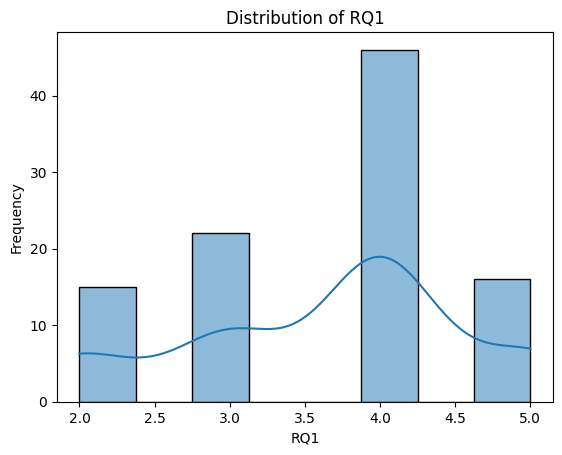

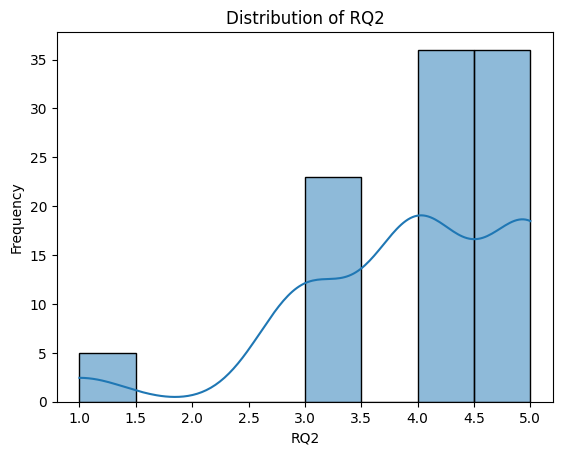

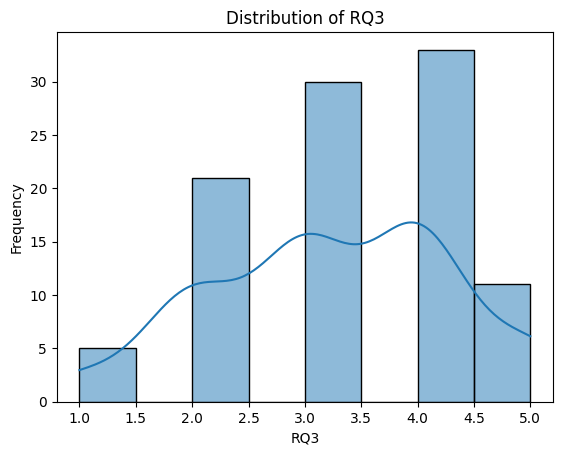

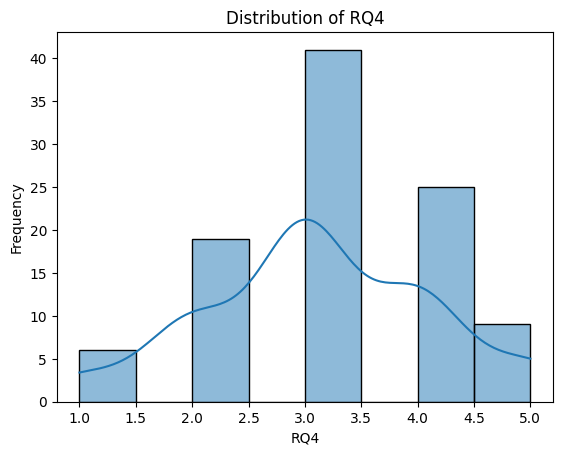

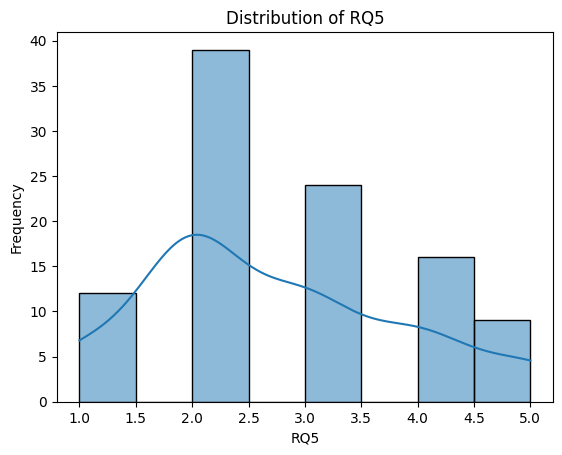

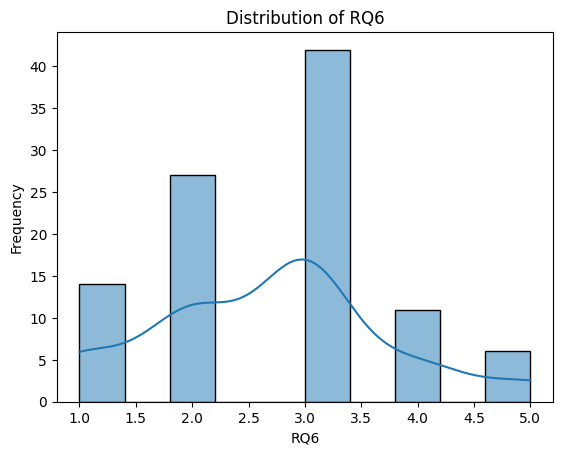

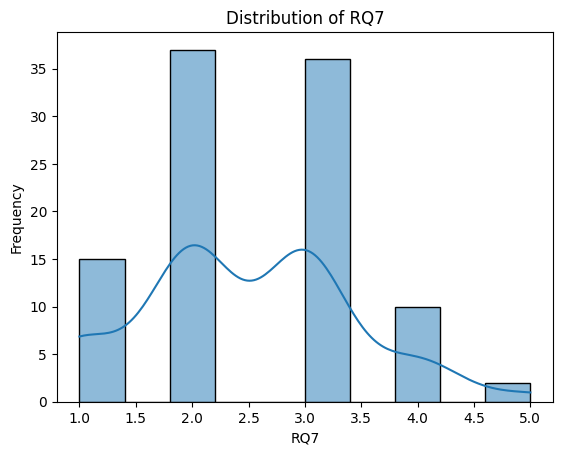

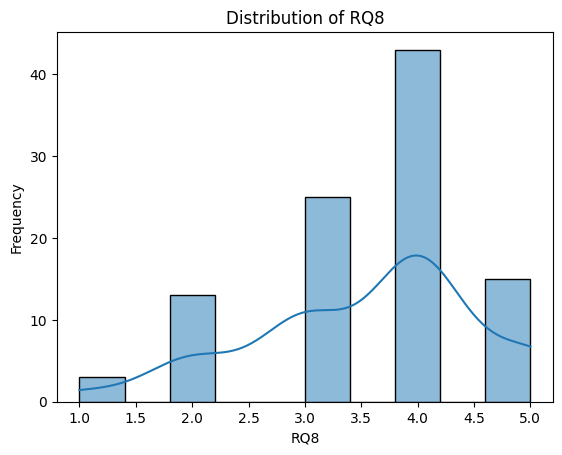

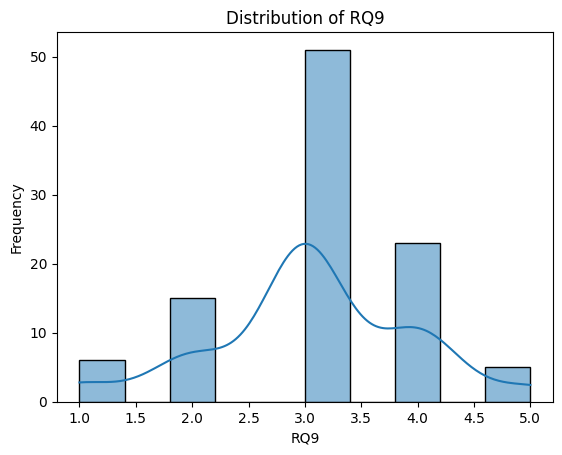

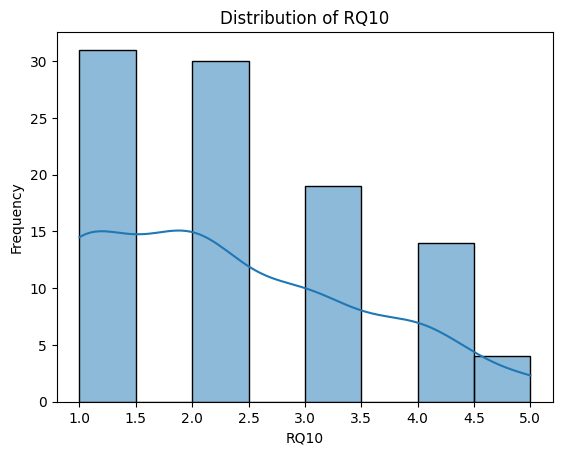

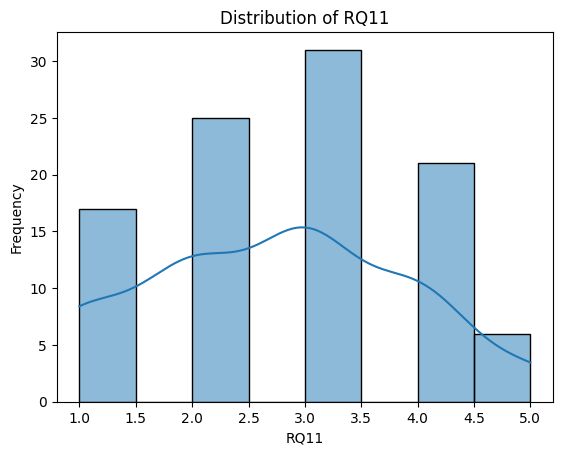

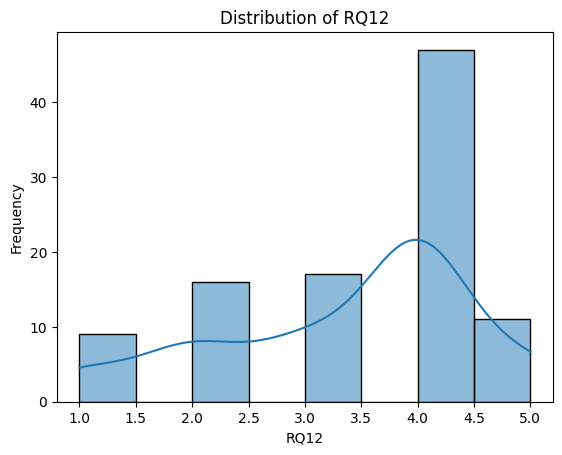

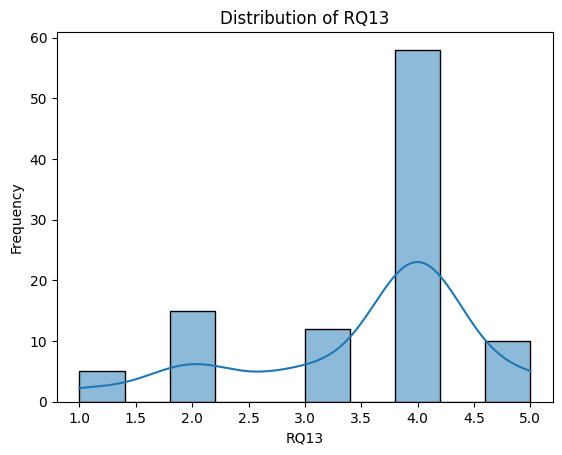

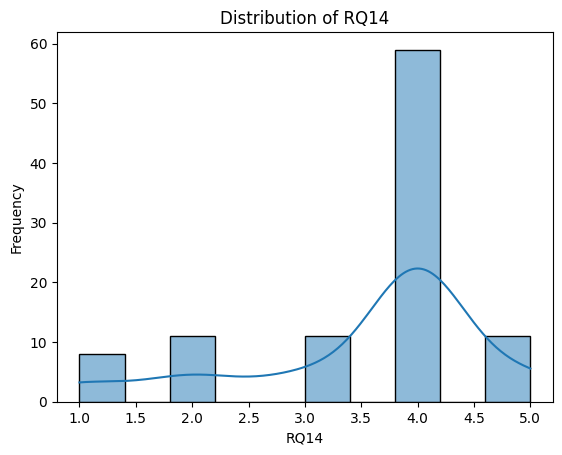

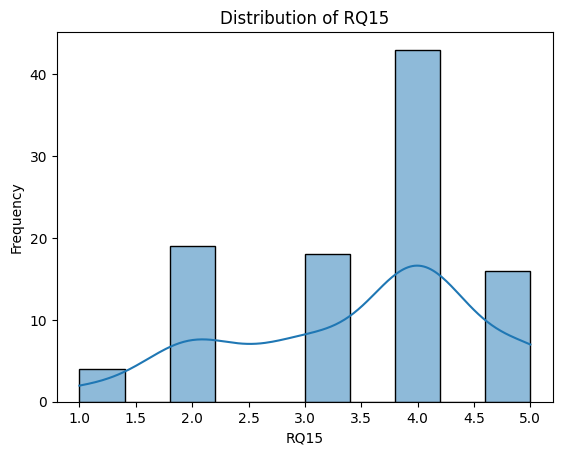

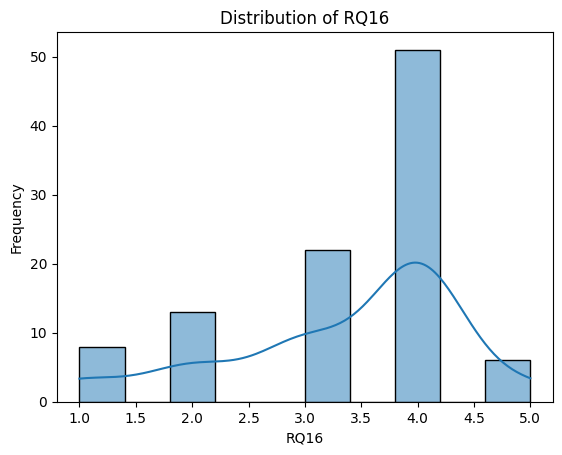

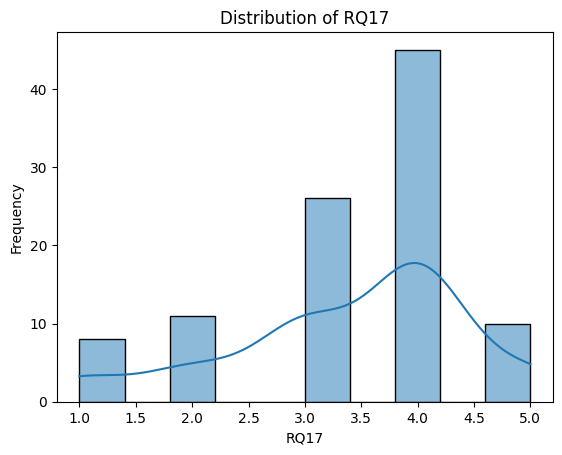

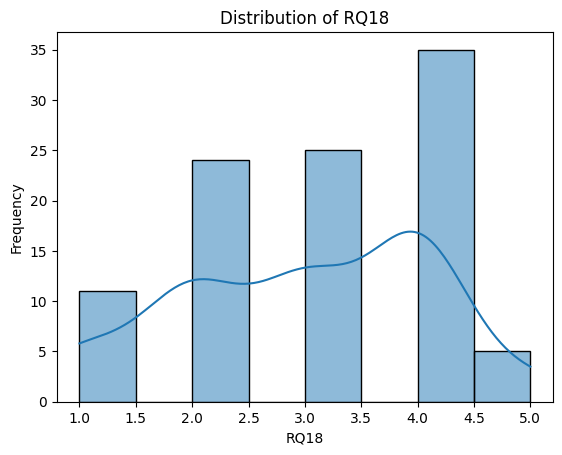

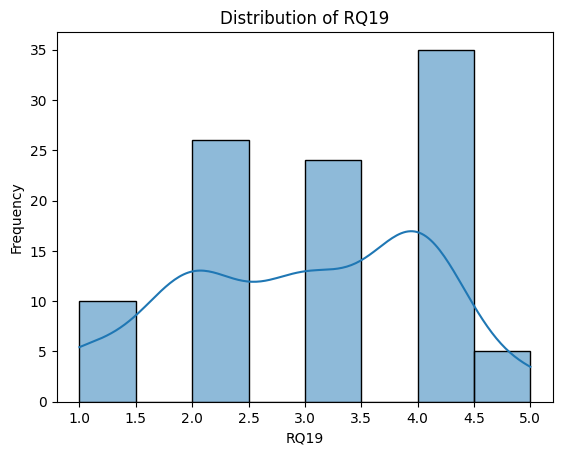

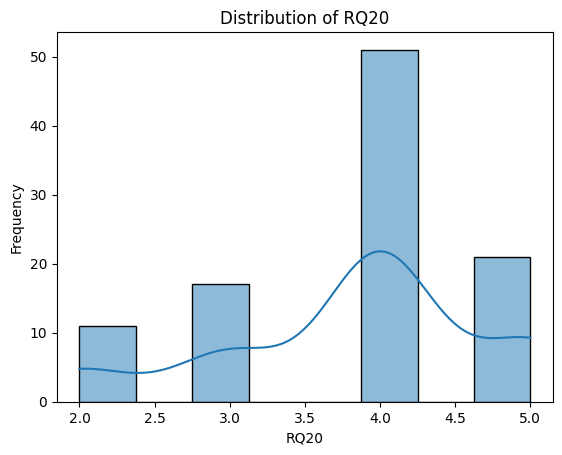

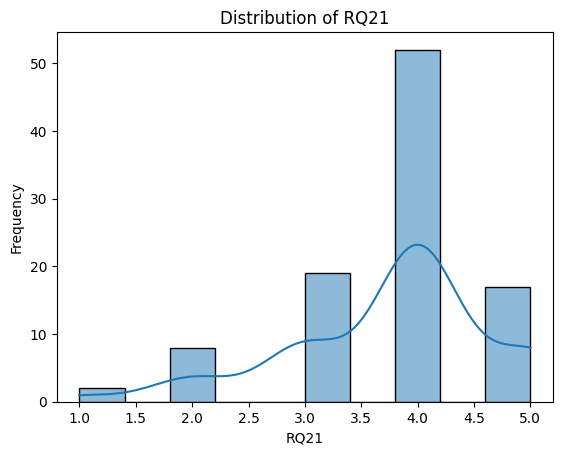

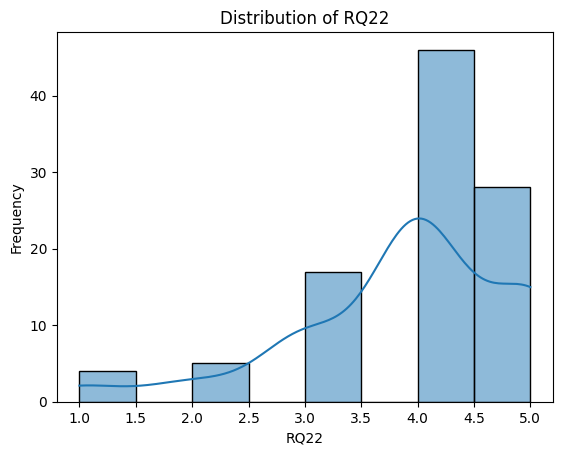

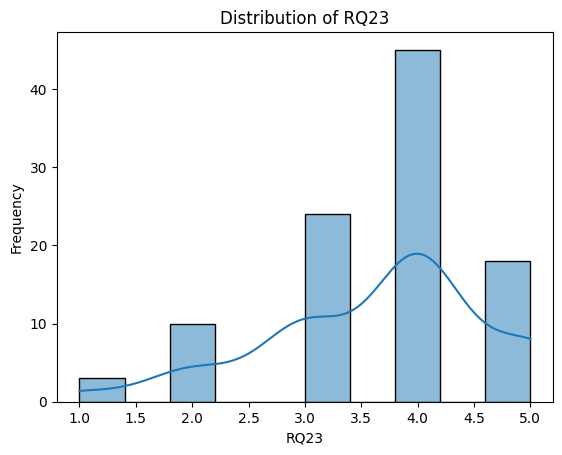

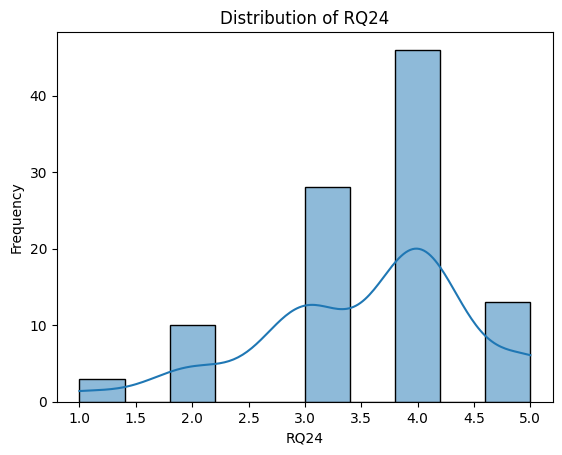

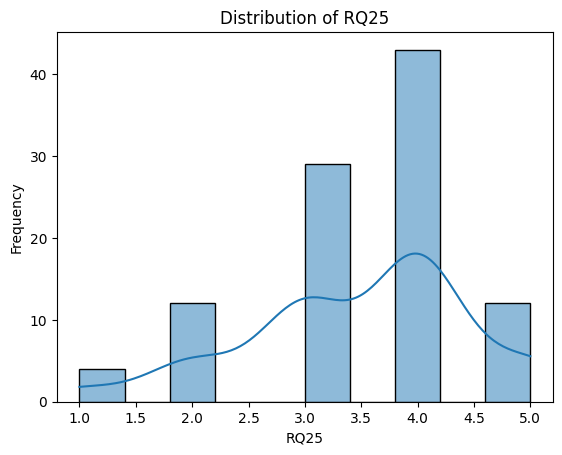

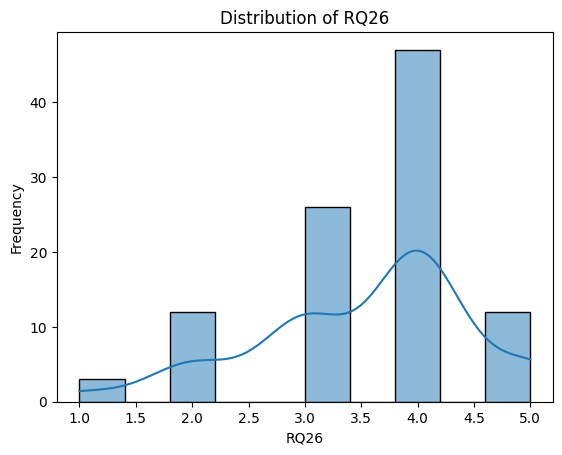

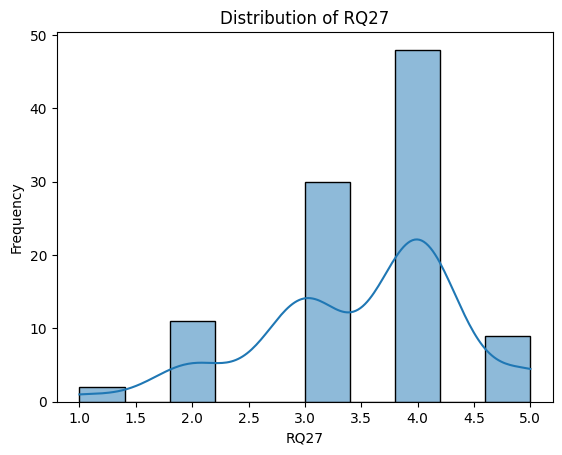

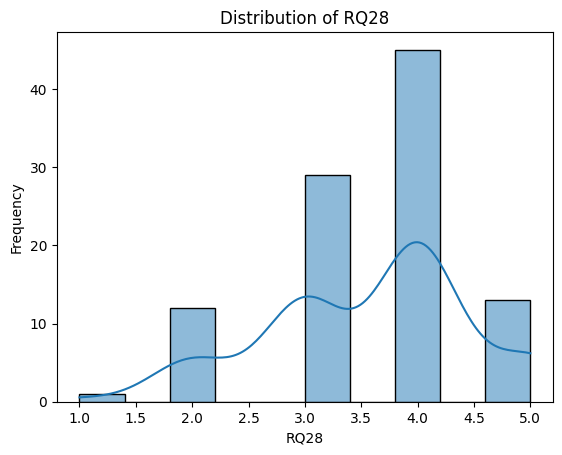

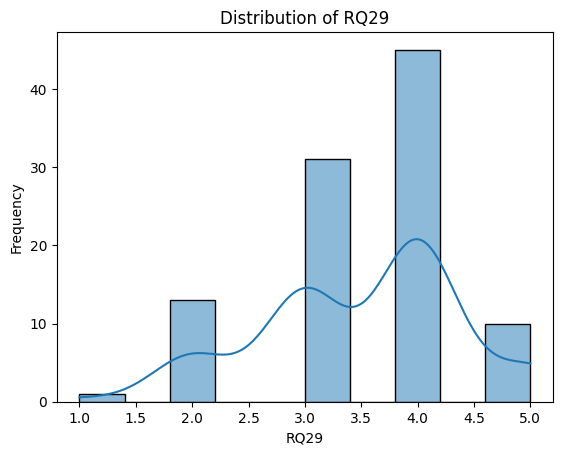

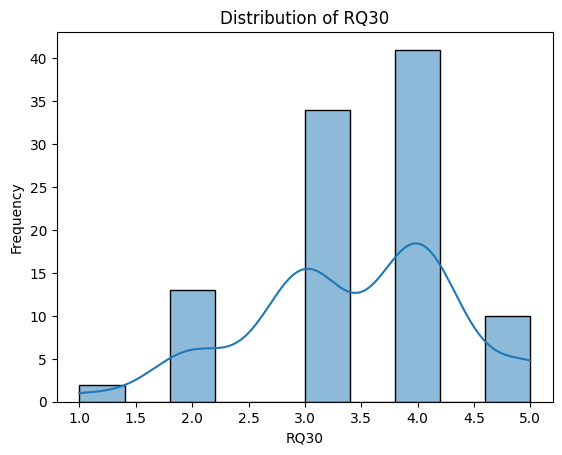

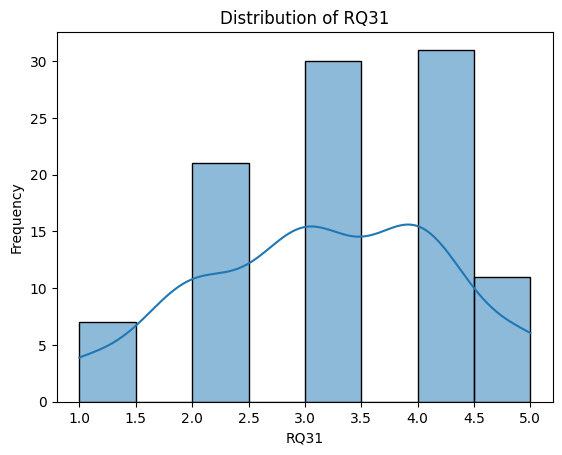

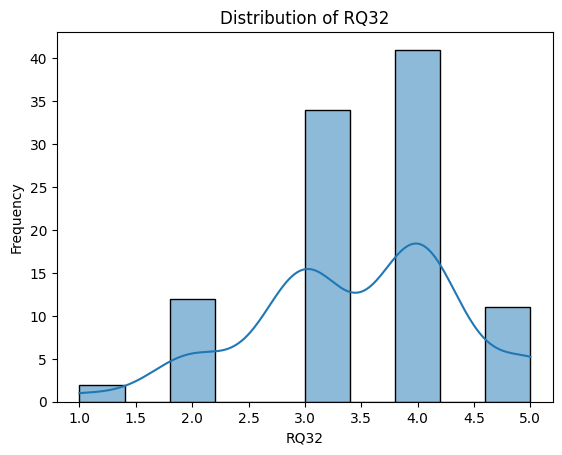

In [58]:
#distribution of the data
for column in df_regression.columns:
    sns.histplot(df_regression[column], kde=True)
    plt.title('Distribution of ' + column)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()


In [68]:
df_regression=df_regression.fillna(df_regression.median())

In [93]:
df_regression.head()

,RQ1,RQ2,RQ3,RQ4,RQ5,RQ6,RQ7,RQ8,RQ9,RQ10,...,RQ23,RQ24,RQ25,RQ26,RQ27,RQ28,RQ29,RQ30,RQ31,RQ32
0,5,5,2,5,1,2,1,5,2,1,...,1,2,4,5,3,2,4,1,5,5
1,2,3,4,4,4,4,3,4,4,5,...,5,2,4,4,4,3,5,4,4,3
2,4,5,3,3,3,3,3,3,4,1,...,2,4,3,3,4,3,2,3,3,3
3,4,5,3,2,2,4,2,2,3,3,...,3,3,4,4,4,4,4,4,5,4
4,4,5,3,4,2,3,2,4,3,1,...,3,3,3,3,3,3,3,3,3,3


Reliability Analysis

In [69]:
import pingouin as pg


#先创建数据集：一个变量一个df
df_DV = df_regression.loc[:,'RQ1':'RQ7']
df_IV1 = df_regression.loc[:,'RQ8':'RQ16']
df_IV2 = df_regression.loc[:,'RQ17':'RQ24']
df_IV3 = df_regression.loc[:,'RQ25':'RQ32']

#计算Cronbach's alpha
alpha_IV1 = pg.cronbach_alpha(df_IV1)
alpha_IV2 = pg.cronbach_alpha(df_IV2)
alpha_IV3 = pg.cronbach_alpha(df_IV3)
alpha_DV = pg.cronbach_alpha(df_DV)

#打印出来结果
print(alpha_IV1)
print(alpha_IV2)
print(alpha_IV3)
print(alpha_DV)

(np.float64(0.8580977306739512), array([0.812, 0.896]))
(np.float64(0.8044872877063847), array([0.741, 0.857]))
(np.float64(0.8771636944111035), array([0.837, 0.91 ]))
(np.float64(0.5682805230376707), array([0.425, 0.686]))


Factor Analaysis - Internal Validity of Constructs

In [123]:
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo

In [ ]:
#use <.to_numpy(dtype=float)> to convert dtype to float (numpy array) for calculate_kmo()
df_IV1=df_IV1.to_numpy(dtype=float)
df_IV2=df_IV2.to_numpy(dtype=float)
df_IV3=df_IV3.to_numpy(dtype=float)
df_DV=df_DV.to_numpy(dtype=float)

In [118]:
kmo_allIV1, kmo_modelIV1 = calculate_kmo(df_IV1)
kmo_allIV2, kmo_modelIV2 = calculate_kmo(df_IV2)
kmo_allIV3, kmo_modelIV3 = calculate_kmo(df_IV3)
kmo_allDV, kmo_modelDV = calculate_kmo(df_DV)
print("KMO IV1:",kmo_modelIV1)
print('KMO IV2:', kmo_modelIV2)
print('KMO IV3:', kmo_modelIV3)
print('KMO DV:', kmo_modelDV)


KMO IV1: 0.8199358504947999
KMO IV2: 0.7607084797944124
KMO IV3: 0.8511056665688682
KMO DV: 0.7254979416018398


In [119]:
print('all variables showed kmo greater than 0.7, which means they are good for factor analysis')

all variables showed kmo greater than 0.7, which means they are good for factor analysis


In [120]:
#Bartlett_Sphericity test

chi_IV1, p_IV1 = calculate_bartlett_sphericity(df_IV1)
chi_IV2, p_IV2 = calculate_bartlett_sphericity(df_IV2)
chi_IV3, p_IV3 = calculate_bartlett_sphericity(df_IV3)
chi_DV, p_DV = calculate_bartlett_sphericity(df_DV)
print(chi_IV1, p_IV1)
print(chi_IV2, p_IV2)
print(chi_IV3, p_IV3)
print(chi_DV, p_DV)

411.1535848905844 3.3566418652620503e-65
232.60026071755877 3.987669394571439e-34
382.2826252394534 7.622998399192471e-64
134.898371430243 1.2384592572550361e-18


In [122]:
print('all variables showed p value less than 0.05, which means they are suitable for factor analysis')

all variables showed p value less than 0.05, which means they are suitable for factor analysis


In [131]:
#use FactorAnalyzer to do factor analysis
fa = FactorAnalyzer(n_factors=1, rotation='Varimax', method='principal')
fa_IV1 = fa.fit(df_IV1)
fa_IV2 = fa.fit(df_IV2)
fa_IV3 = fa.fit(df_IV3)
fa_DV = fa.fit(df_DV)

loadings_IV1 = fa_IV1.loadings_
loadings_IV2 = fa_IV2.loadings_
loadings_IV3 = fa_IV3.loadings_
loadings_DV = fa_DV.loadings_
print("Loadings IV1:", loadings_IV1)
print("Loadings IV2:", loadings_IV2)
print("Loadings IV3:", loadings_IV3)
print("Loadings DV", loadings_DV)



Loadings IV1: [[-0.5460405 ]
 [-0.52505783]
 [-0.67958805]
 [-0.71331347]
 [-0.70442748]
 [-0.60642719]
 [ 0.51285497]]
Loadings IV2: [[-0.5460405 ]
 [-0.52505783]
 [-0.67958805]
 [-0.71331347]
 [-0.70442748]
 [-0.60642719]
 [ 0.51285497]]
Loadings IV3: [[-0.5460405 ]
 [-0.52505783]
 [-0.67958805]
 [-0.71331347]
 [-0.70442748]
 [-0.60642719]
 [ 0.51285497]]
Loadings DV [[-0.5460405 ]
 [-0.52505783]
 [-0.67958805]
 [-0.71331347]
 [-0.70442748]
 [-0.60642719]
 [ 0.51285497]]


C:\Users\lilai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\lilai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\factor_analyzer\factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(
C:\Users\lilai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\lilai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packag

In [132]:
print('All variables showed factor loadings greater than 0.5, which means they are good indicators for their respective constructs.')

All variables showed factor loadings greater than 0.5, which means they are good indicators for their respective constructs.


Hence, both reliability, KMO, bartlett's sphericity test and a factor analysis was done, which has affectively proven the structural validity of data.

Next, the regression model will be built using the data, following along with assumption tests.

In [137]:
#generating factor score

Willingness = df_IV1.mean(axis=1)
Reflection = df_IV2.mean(axis=1)
Trust = df_IV3.mean(axis=1)
Engagement = df_DV.mean(axis=1)

df_factor = pd.DataFrame ({
    'Willingness':Willingness,
    'Reflection':Reflection,
    'Trust':Trust,
    'Engagement':Engagement
})


df_factor.to_csv('factor_score.csv')

In [ ]:
#apply multiple linear regression mode using pingouin

X = df_factor[['Willingness', 'Reflection', 'Trust']]
y = df_factor['Engagement']

model = pg.linear_regression(X, y)

model

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,1.242692,0.257613,4.823864,0.000005,0.426055,0.408119,0.731333,1.754050
1,Willingness,0.355050,0.079458,4.468372,0.000022,0.426055,0.408119,0.197326,0.512774
2,Reflection,0.084382,0.088233,0.956361,0.341292,0.426055,0.408119,-0.090758,0.259523
3,Trust,0.127973,0.070400,1.817802,0.072213,0.426055,0.408119,-0.011770,0.267715


In [145]:
#apply multiple linear regression mode using statsmodels
import statsmodels.api as sm
X = sm.add_constant(X) #手动添加截距项

model = sm.OLS(y, X).fit()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:             Engagement   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                     23.75
Date:                 周四, 27 11月 2025   Prob (F-statistic):           1.39e-11
Time:                        20:03:27   Log-Likelihood:                -52.255
No. Observations:                 100   AIC:                             112.5
Df Residuals:                      96   BIC:                             122.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.2427      0.258      4.824      

至此，回归分析结果已出。关注并解读其中几个关键指标:

1. R-sqaured. 该指标表示模型的拟合程度。这里为0.426，说明模型拟合程度一般。
2. p-value. 整体显著性是0.000 所以模型是有效的

接下来细看变量：
1. 变量显著性。首先，这里仅willingness 表现显著，道标他是惟一证明能顾显著影响因变量的自变量。其次，Trust可能存在若效应，或被样本量或其他因素限制显著性。
2. 回归系数。每个变量的回归系数代表影响的程度。这里仅IV1表现显著所以无法排序。

回归模型假设检验：
1. 残差正态分布。Omnibus 检验
    Prob(Omnibus): 0.514
    Prob（JB）:0.663
    不显著，因此无法拒绝残差正态分布假设。
    Skew: 0.006
    Kurtosis: 3.444
    残差分布无偏态，因此残差正态分布成立。
2. 残差不能自相关。
    Durbin-Watson: 1.86
    约等于2，因此残差不存在自相关成立。
3. 多重共线性：自变量不能存在共线性。
    Condition Number: 38.1
    偏高，应结合variance inflation factor (VIF) 来判断自变量的共线性。

In [153]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_Willingness = variance_inflation_factor(X.values,1) #among X, 0 is constant therefore skipped
vif_Reflection = variance_inflation_factor(X.values,2)
vif_Trust = variance_inflation_factor(X.values,3)

print(vif_Willingness)
print(vif_Reflection)
print(vif_Trust)

1.943032798431462
1.8992085685037108
1.3610126541442584


所有变量的variane inflation factor 均小于5， 因此自变量不存在多重共线性。

至此，所有假设检验步骤均完成。

得出结论：消费者自助willingness是一个显著正向影响消费者参与度的变量。